# YOLOv1 Detection Test (Pascal VOC 2012 val, mAP@0.5)

Loads the epoch-60 checkpoint produced by `YOLO_train.ipynb` and reports
Pascal VOC mAP@0.5 (per-class AP + overall mAP) on the VOC2012 `val` split.

- Checkpoint: `yolo-epoch60.npz` from Google Drive
- Split: VOC2012 `val` (no augmentation)
- Decoder: raw model output (no sigmoid / no sqrt) — matches `loss.py`
- NMS: greedy per-class at IoU 0.5
- Metric: Pascal VOC mAP@0.5 with all-point interpolation (post-2010 VOC)


In [1]:
!nvidia-smi

Mon May  4 16:07:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             49W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Clone the repo fresh and put it on sys.path (mirrors YOLO_train.ipynb).
!rm -rf /content/yolov1-cupy
!git clone https://github.com/mihnea-popescu/yolov1-cupy.git

import sys
sys.path.append('/content/yolov1-cupy')

from main import TestClass
test = TestClass()
test.test()

Cloning into 'yolov1-cupy'...
remote: Enumerating objects: 219, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 219 (delta 31), reused 43 (delta 16), pack-reused 159 (from 1)
Receiving objects: 100% (219/219), 85.91 MiB | 2.13 MiB/s, done.
Resolving deltas: 100% (114/114), done.
Github classes initialized!


In [3]:
# Pascal VOC 2012 dataset download + extract (Kaggle), same as training.
!curl -L -o /content/pascal-voc-2012-dataset.zip https://www.kaggle.com/api/v1/datasets/download/gopalbhattrai/pascal-voc-2012-dataset
print("Extracting Pascal VOC dataset (quiet unzip)...")
!unzip -q /content/pascal-voc-2012-dataset.zip -d /content/yolov1-cupy
!rm /content/pascal-voc-2012-dataset.zip
print("Pascal VOC dataset ready under /content/yolov1-cupy (VOC2012_train_val / VOC2012_test)")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 3605M  100 3605M    0     0  36.4M      0  0:01:39  0:01:39 --:--:-- 38.4M
Extracting Pascal VOC dataset (quiet unzip)...
Pascal VOC dataset ready under /content/yolov1-cupy (VOC2012_train_val / VOC2012_test)


In [4]:
# Mount Drive and locate the epoch-60 checkpoint. We copy it to local disk so
# repeated npz reads don't go through Drive's FUSE layer.
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

PATH_PREFIX = "/content/drive/MyDrive/GWU_Machine-Learning-Final-Project/v2"
DRIVE_CKPT_PATH = f"{PATH_PREFIX}/checkpoints/yolo-v2-best.npz"
LOCAL_CKPT_PATH = "/content/yolov1-cupy/yolo-v2-best.npz"

assert os.path.isfile(DRIVE_CKPT_PATH), f"Not found in Drive: {DRIVE_CKPT_PATH}"
shutil.copy2(DRIVE_CKPT_PATH, LOCAL_CKPT_PATH)
print("Epoch-60 checkpoint copied to", LOCAL_CKPT_PATH)

Mounted at /content/drive
Epoch-60 checkpoint copied to /content/yolov1-cupy/yolo-v2-best.npz


In [5]:
# Imports.
import numpy as np
import cupy as cp
from tqdm.auto import tqdm

from yolo import YOLO
from image_batch_loader import (
    voc_image_target_batch_fast,
    BatchPrefetcher,
    voc_dataset_size,
    voc_num_batches_per_epoch,
    VOC_CLASS_NAMES,
)
print("Imports OK. Number of VOC classes:", len(VOC_CLASS_NAMES))

Imports OK. Number of VOC classes: 20


## Hyperparameters

Match the training notebook (S, B, C, image size, batch size). Detection thresholds
follow the Pascal VOC convention: a low score threshold to keep the full PR curve,
NMS IoU 0.5, and mAP IoU 0.5.

In [6]:
S, B, C = 7, 2, 20
IMG_SIZE = (448, 448)
BATCH_SIZE = 64

REPO_ROOT = "/content/yolov1-cupy"
VOC_DATA_ROOT = "/content/yolov1-cupy"
CKPT_PATH = LOCAL_CKPT_PATH  # /content/yolov1-cupy/yolo-epoch60.npz

SCORE_THRESH = 0.05    # Pascal VOC convention: keep low-score detections for the PR curve
NMS_IOU_THRESH = 0.5
MAP_IOU_THRESH = 0.5

print("Config:")
print(f"  S, B, C       = {S}, {B}, {C}")
print(f"  IMG_SIZE      = {IMG_SIZE}")
print(f"  BATCH_SIZE    = {BATCH_SIZE}")
print(f"  CKPT_PATH     = {CKPT_PATH}")
print(f"  SCORE_THRESH  = {SCORE_THRESH}")
print(f"  NMS_IOU_THRESH= {NMS_IOU_THRESH}")
print(f"  MAP_IOU_THRESH= {MAP_IOU_THRESH}")

Config:
  S, B, C       = 7, 2, 20
  IMG_SIZE      = (448, 448)
  BATCH_SIZE    = 64
  CKPT_PATH     = /content/yolov1-cupy/yolo-v2-best.npz
  SCORE_THRESH  = 0.05
  NMS_IOU_THRESH= 0.5
  MAP_IOU_THRESH= 0.5


## Load the trained model (epoch 60)

Instantiate the YOLOv1 model, load the epoch-60 weights, and switch to eval mode
so Dropout is disabled and BatchNorm uses the running statistics from training.
We also monkey-patch `forward` to silence the per-layer debug print baked into
`yolo.py` (otherwise every batch logs ~16 lines).

In [7]:
import types

yolo = YOLO(num_classes=C)
yolo.load_weights(CKPT_PATH)
yolo.eval()  # disables Dropout, freezes BN stats


def _silent_forward(self, x):
    assert x.ndim == 4, f"Expected NCHW, got shape {x.shape}"
    assert x.shape[1] == 3, f"Expected 3 input channels, got {x.shape[1]}"
    for layer in self.backbone:
        x = layer.forward(x)
    for layer in self.head:
        x = layer.forward(x)
    return x


yolo.forward = types.MethodType(_silent_forward, yolo)
print(f"Loaded YOLOv1 weights from {CKPT_PATH}")
print(f"Model is in eval mode; head output shape per image = ({S*S*(B*5+C)},) -> reshape ({S},{S},{B*5+C})")

Loaded YOLOv1 weights from /content/yolov1-cupy/yolo-v2-best.npz
Model is in eval mode; head output shape per image = (1470,) -> reshape (7,7,30)


## Prediction decoder + NMS (NumPy helpers)

Per-cell layout matches `loss.py`:

- For each cell `(i, j)` and each box slot `b in {0, 1}`:
  - `cx = (j + p[i,j,b*5+0]) / S`, `cy = (i + p[i,j,b*5+1]) / S`  (image-normalized)
  - `w  = max(p[i,j,b*5+2], 0)`, `h = max(p[i,j,b*5+3], 0)`        (image-normalized)
  - `obj_conf = p[i,j,b*5+4]`
- Class probabilities `p[i,j,10:30]` are shared across the two boxes (paper).
- Per-box per-class detection score = `obj_conf * class_prob_c`            (paper Eq. 1).

Predictions are **raw** — no sigmoid, no sqrt — because `loss.py` operates on the
same raw values, so the trained network's outputs already live in this geometry.

In [8]:
def _cells_to_xyxy(cx_cell, cy_cell, w_img, h_img, i_idx, j_idx, s):
    """Convert YOLOv1 cell-relative (cx, cy) + image-relative (w, h) to image-normalized (x1,y1,x2,y2)."""
    cx = (j_idx + cx_cell) / s
    cy = (i_idx + cy_cell) / s
    x1 = cx - 0.5 * w_img
    y1 = cy - 0.5 * h_img
    x2 = cx + 0.5 * w_img
    y2 = cy + 0.5 * h_img
    return x1, y1, x2, y2


def decode_predictions(pred_grid, score_thresh=SCORE_THRESH, s=S, b=B, c=C):
    """
    Decode raw YOLOv1 predictions for one image.

    Args:
        pred_grid: np.ndarray of shape (s, s, b*5+c), raw logits.

    Returns:
        boxes  : np.ndarray (K, 4) in image-normalized xyxy, clipped to [0, 1]
        scores : np.ndarray (K,)
        classes: np.ndarray (K,) int
    """
    assert pred_grid.shape == (s, s, b * 5 + c), pred_grid.shape

    # Class head is trained with softmax + cross-entropy (see loss.py), so the
    # raw outputs are logits. Apply softmax along the class axis before
    # combining with objectness to get the final detection score.
    _cls_logits = pred_grid[..., b * 5:]
    _z = _cls_logits - _cls_logits.max(axis=-1, keepdims=True)
    _ez = np.exp(_z)
    class_probs = _ez / _ez.sum(axis=-1, keepdims=True)  # (s, s, c)

    boxes_out, scores_out, classes_out = [], [], []
    for box_slot in range(b):
        off = box_slot * 5
        cx_cell = pred_grid[..., off + 0]
        cy_cell = pred_grid[..., off + 1]
        w_img = np.maximum(pred_grid[..., off + 2], 0.0)
        h_img = np.maximum(pred_grid[..., off + 3], 0.0)
        obj_conf = pred_grid[..., off + 4]

        i_idx, j_idx = np.indices((s, s))
        x1, y1, x2, y2 = _cells_to_xyxy(cx_cell, cy_cell, w_img, h_img, i_idx, j_idx, s)

        # Per-box per-class score, shape (s, s, c).
        det_scores = obj_conf[..., None] * class_probs

        # Flatten cells, then expand the per-class axis.
        x1f = x1.reshape(-1)
        y1f = y1.reshape(-1)
        x2f = x2.reshape(-1)
        y2f = y2.reshape(-1)
        scores_f = det_scores.reshape(-1, c)  # (s*s, c)

        keep = scores_f > score_thresh        # (s*s, c)
        if not keep.any():
            continue
        cell_idx, class_idx = np.where(keep)
        boxes_out.append(np.stack([x1f[cell_idx], y1f[cell_idx],
                                   x2f[cell_idx], y2f[cell_idx]], axis=1))
        scores_out.append(scores_f[cell_idx, class_idx])
        classes_out.append(class_idx)

    if not boxes_out:
        return (np.zeros((0, 4), dtype=np.float32),
                np.zeros((0,), dtype=np.float32),
                np.zeros((0,), dtype=np.int64))

    boxes = np.concatenate(boxes_out, axis=0).astype(np.float32)
    scores = np.concatenate(scores_out, axis=0).astype(np.float32)
    classes = np.concatenate(classes_out, axis=0).astype(np.int64)

    # Clip to [0, 1] and drop degenerate boxes.
    boxes = np.clip(boxes, 0.0, 1.0)
    valid = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
    return boxes[valid], scores[valid], classes[valid]


def decode_targets(target_grid, s=S, b=B, c=C):
    """
    Decode the (s, s, b*5+c) ground-truth tensor back into image-normalized xyxy boxes.

    Returns:
        gt_boxes  : np.ndarray (M, 4)
        gt_classes: np.ndarray (M,) int
    """
    assert target_grid.shape == (s, s, b * 5 + c), target_grid.shape

    class_probs = target_grid[..., b * 5:]  # one-hot per responsible cell
    gt_boxes, gt_classes = [], []

    for box_slot in range(b):
        off = box_slot * 5
        conf = target_grid[..., off + 4]
        # encode_yolov1_target() writes confidence==1 for the responsible slot only.
        ii, jj = np.where(conf > 0.5)
        if ii.size == 0:
            continue
        cx_cell = target_grid[ii, jj, off + 0]
        cy_cell = target_grid[ii, jj, off + 1]
        w_img = target_grid[ii, jj, off + 2]
        h_img = target_grid[ii, jj, off + 3]
        x1, y1, x2, y2 = _cells_to_xyxy(cx_cell, cy_cell, w_img, h_img, ii, jj, s)
        gt_boxes.append(np.stack([x1, y1, x2, y2], axis=1))
        gt_classes.append(np.argmax(class_probs[ii, jj], axis=1))

    if not gt_boxes:
        return (np.zeros((0, 4), dtype=np.float32),
                np.zeros((0,), dtype=np.int64))

    boxes = np.clip(np.concatenate(gt_boxes, axis=0), 0.0, 1.0).astype(np.float32)
    classes = np.concatenate(gt_classes, axis=0).astype(np.int64)
    return boxes, classes


def _iou_xyxy(boxes_a, boxes_b):
    """Vectorized IoU between two sets of xyxy boxes. Returns (A, B)."""
    if boxes_a.size == 0 or boxes_b.size == 0:
        return np.zeros((boxes_a.shape[0], boxes_b.shape[0]), dtype=np.float32)
    ax1, ay1, ax2, ay2 = boxes_a[:, 0:1], boxes_a[:, 1:2], boxes_a[:, 2:3], boxes_a[:, 3:4]
    bx1, by1, bx2, by2 = boxes_b[:, 0], boxes_b[:, 1], boxes_b[:, 2], boxes_b[:, 3]
    inter_x1 = np.maximum(ax1, bx1)
    inter_y1 = np.maximum(ay1, by1)
    inter_x2 = np.minimum(ax2, bx2)
    inter_y2 = np.minimum(ay2, by2)
    inter_w = np.clip(inter_x2 - inter_x1, a_min=0.0, a_max=None)
    inter_h = np.clip(inter_y2 - inter_y1, a_min=0.0, a_max=None)
    inter = inter_w * inter_h
    area_a = np.clip(ax2 - ax1, 0.0, None) * np.clip(ay2 - ay1, 0.0, None)
    area_b = np.clip(bx2 - bx1, 0.0, None) * np.clip(by2 - by1, 0.0, None)
    union = area_a + area_b - inter
    return np.where(union > 0, inter / np.maximum(union, 1e-12), 0.0).astype(np.float32)


def nms_per_class(boxes, scores, classes, iou_thresh=NMS_IOU_THRESH):
    """Greedy per-class NMS. Returns (boxes, scores, classes) in score-desc order."""
    if boxes.shape[0] == 0:
        return boxes, scores, classes

    keep_boxes, keep_scores, keep_classes = [], [], []
    for c_id in np.unique(classes):
        mask = classes == c_id
        cls_boxes = boxes[mask]
        cls_scores = scores[mask]
        order = np.argsort(-cls_scores)
        cls_boxes = cls_boxes[order]
        cls_scores = cls_scores[order]

        suppressed = np.zeros(cls_boxes.shape[0], dtype=bool)
        for i in range(cls_boxes.shape[0]):
            if suppressed[i]:
                continue
            keep_boxes.append(cls_boxes[i])
            keep_scores.append(cls_scores[i])
            keep_classes.append(c_id)
            if i + 1 < cls_boxes.shape[0]:
                ious = _iou_xyxy(cls_boxes[i:i + 1], cls_boxes[i + 1:])[0]
                suppressed[i + 1:] |= ious >= iou_thresh

    if not keep_boxes:
        return (np.zeros((0, 4), dtype=np.float32),
                np.zeros((0,), dtype=np.float32),
                np.zeros((0,), dtype=np.int64))

    out_boxes = np.stack(keep_boxes, axis=0).astype(np.float32)
    out_scores = np.array(keep_scores, dtype=np.float32)
    out_classes = np.array(keep_classes, dtype=np.int64)
    # Final sort by score so downstream AP computation gets a single sorted stream per class.
    final_order = np.argsort(-out_scores)
    return out_boxes[final_order], out_scores[final_order], out_classes[final_order]


print("Decoder + NMS helpers ready.")

Decoder + NMS helpers ready.


## Inference loop over the VOC2012 val split

Iterate the val split with `BatchPrefetcher(augment=False)`. For each batch we
take a single forward pass, move the logits and the ground-truth grid to NumPy,
then decode + NMS each image and append `(boxes, scores, classes)` /
`(gt_boxes, gt_classes)` to parallel lists.

In [9]:
n_val = voc_dataset_size(REPO_ROOT, data_root=VOC_DATA_ROOT, split="val")
n_batches = voc_num_batches_per_epoch(
    REPO_ROOT, BATCH_SIZE, data_root=VOC_DATA_ROOT, split="val",
)
print(f"VOC2012 val: {n_val} images, {n_batches} batches of {BATCH_SIZE}")

prefetcher = BatchPrefetcher(
    REPO_ROOT, BATCH_SIZE,
    seed=0, data_root=VOC_DATA_ROOT, split="val",
    n_batches=n_batches, size=IMG_SIZE, s=S, b=B, c=C,
    augment=False,
)

all_preds = []  # parallel list of (boxes, scores, classes) per image
all_gts = []    # parallel list of (gt_boxes, gt_classes)   per image

try:
    for x, y in tqdm(prefetcher, total=n_batches, desc="val inference"):
        logits = yolo.forward(x)                                      # (N, 7*7*30)
        n = logits.shape[0]
        pred_grid = cp.asnumpy(logits.reshape(n, S, S, B * 5 + C))
        tgt_grid = cp.asnumpy(y)                                      # (N, 7, 7, 30)

        for i in range(n):
            boxes, scores, classes = decode_predictions(pred_grid[i])
            boxes, scores, classes = nms_per_class(boxes, scores, classes, NMS_IOU_THRESH)
            all_preds.append((boxes, scores, classes))
            all_gts.append(decode_targets(tgt_grid[i]))
finally:
    prefetcher.close()

n_pred_total = sum(b.shape[0] for b, _, _ in all_preds)
n_gt_total = sum(b.shape[0] for b, _ in all_gts)
print(f"Collected predictions for {len(all_preds)} images")
print(f"  total predictions after NMS : {n_pred_total}")
print(f"  total ground-truth boxes    : {n_gt_total}")

VOC2012 val: 5823 images, 91 batches of 64


val inference:   0%|          | 0/91 [00:00<?, ?it/s]

Collected predictions for 5823 images
  total predictions after NMS : 116088
  total ground-truth boxes    : 13706


## Pascal VOC mAP@0.5

Per-class AP via the post-2010 VOC convention (all-point interpolation):

\[ AP = \sum_i (r_{i+1} - r_i)\, p_\text{interp}(r_{i+1}),\quad
   p_\text{interp}(r) = \max_{r' \ge r} p(r'). \]

For each class:

1. Flatten predictions across all images, sort by descending score.
2. Greedy match each prediction to its highest-IoU GT of the same class in the same image.
   A match counts as a TP iff `IoU >= MAP_IOU_THRESH` and that GT hasn't already been used.
3. Build cumulative precision / recall arrays, then integrate via all-point interpolation.

In [10]:
def voc_ap_all_point(rec, prec):
    """Pascal VOC post-2010 all-point interpolation AP."""
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    # Make precision monotonically decreasing (right-to-left max).
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    # Sum over recall steps where it changes.
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


def voc_eval_per_class(all_preds, all_gts, class_idx, iou_thresh=MAP_IOU_THRESH):
    """
    Pascal VOC AP for a single class.

    all_preds: list of (boxes, scores, classes) per image.
    all_gts  : list of (gt_boxes, gt_classes)   per image.
    """
    # Per-image GT for this class + a "matched" flag.
    gt_boxes_per_image = []
    gt_matched_per_image = []
    n_gt = 0
    for gt_boxes, gt_classes in all_gts:
        mask = gt_classes == class_idx
        boxes = gt_boxes[mask]
        gt_boxes_per_image.append(boxes)
        gt_matched_per_image.append(np.zeros(boxes.shape[0], dtype=bool))
        n_gt += boxes.shape[0]

    if n_gt == 0:
        return float("nan")  # no GT for this class; AP undefined

    # Flatten predictions for this class.
    image_ids = []
    pred_boxes = []
    pred_scores = []
    for img_id, (boxes, scores, classes) in enumerate(all_preds):
        mask = classes == class_idx
        if not mask.any():
            continue
        sel_boxes = boxes[mask]
        sel_scores = scores[mask]
        image_ids.extend([img_id] * sel_boxes.shape[0])
        pred_boxes.append(sel_boxes)
        pred_scores.append(sel_scores)

    if not pred_boxes:
        return 0.0

    image_ids = np.asarray(image_ids, dtype=np.int64)
    pred_boxes = np.concatenate(pred_boxes, axis=0)
    pred_scores = np.concatenate(pred_scores, axis=0)

    order = np.argsort(-pred_scores)
    image_ids = image_ids[order]
    pred_boxes = pred_boxes[order]

    tp = np.zeros(pred_boxes.shape[0], dtype=np.float32)
    fp = np.zeros(pred_boxes.shape[0], dtype=np.float32)
    for k in range(pred_boxes.shape[0]):
        img_id = int(image_ids[k])
        gt_boxes_img = gt_boxes_per_image[img_id]
        if gt_boxes_img.shape[0] == 0:
            fp[k] = 1.0
            continue
        ious = _iou_xyxy(pred_boxes[k:k + 1], gt_boxes_img)[0]
        best = int(np.argmax(ious))
        if ious[best] >= iou_thresh and not gt_matched_per_image[img_id][best]:
            tp[k] = 1.0
            gt_matched_per_image[img_id][best] = True
        else:
            fp[k] = 1.0

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)
    rec = cum_tp / float(n_gt)
    prec = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)
    return voc_ap_all_point(rec, prec)


per_class_ap = {
    name: voc_eval_per_class(all_preds, all_gts, idx, MAP_IOU_THRESH)
    for idx, name in enumerate(VOC_CLASS_NAMES)
}

valid_aps = [ap for ap in per_class_ap.values() if not np.isnan(ap)]
mAP = float(np.mean(valid_aps)) if valid_aps else float("nan")

print("=" * 50)
print(f"Pascal VOC 2012 val mAP@{MAP_IOU_THRESH:.2f}")
print("=" * 50)
print(f"{'class':<14s}{'AP':>10s}")
print("-" * 24)
for name, ap in sorted(per_class_ap.items(), key=lambda kv: -(kv[1] if not np.isnan(kv[1]) else -1.0)):
    if np.isnan(ap):
        print(f"{name:<14s}{'n/a':>10s}")
    else:
        print(f"{name:<14s}{ap*100:>9.2f}%")
print("-" * 24)
print(f"{'mAP':<14s}{mAP*100:>9.2f}%")
print("=" * 50)

Pascal VOC 2012 val mAP@0.50
class                 AP
------------------------
person             1.81%
aeroplane          0.00%
bicycle            0.00%
bird               0.00%
boat               0.00%
bottle             0.00%
bus                0.00%
car                0.00%
cat                0.00%
chair              0.00%
cow                0.00%
diningtable        0.00%
dog                0.00%
horse              0.00%
motorbike          0.00%
pottedplant        0.00%
sheep              0.00%
sofa               0.00%
train              0.00%
tvmonitor          0.00%
------------------------
mAP                0.09%


## Qualitative spot-check

Pull a fresh batch from val, render 4 random images, draw ground-truth boxes in
green and post-NMS predictions in red. Strictly diagnostic — the metric is the
table above.

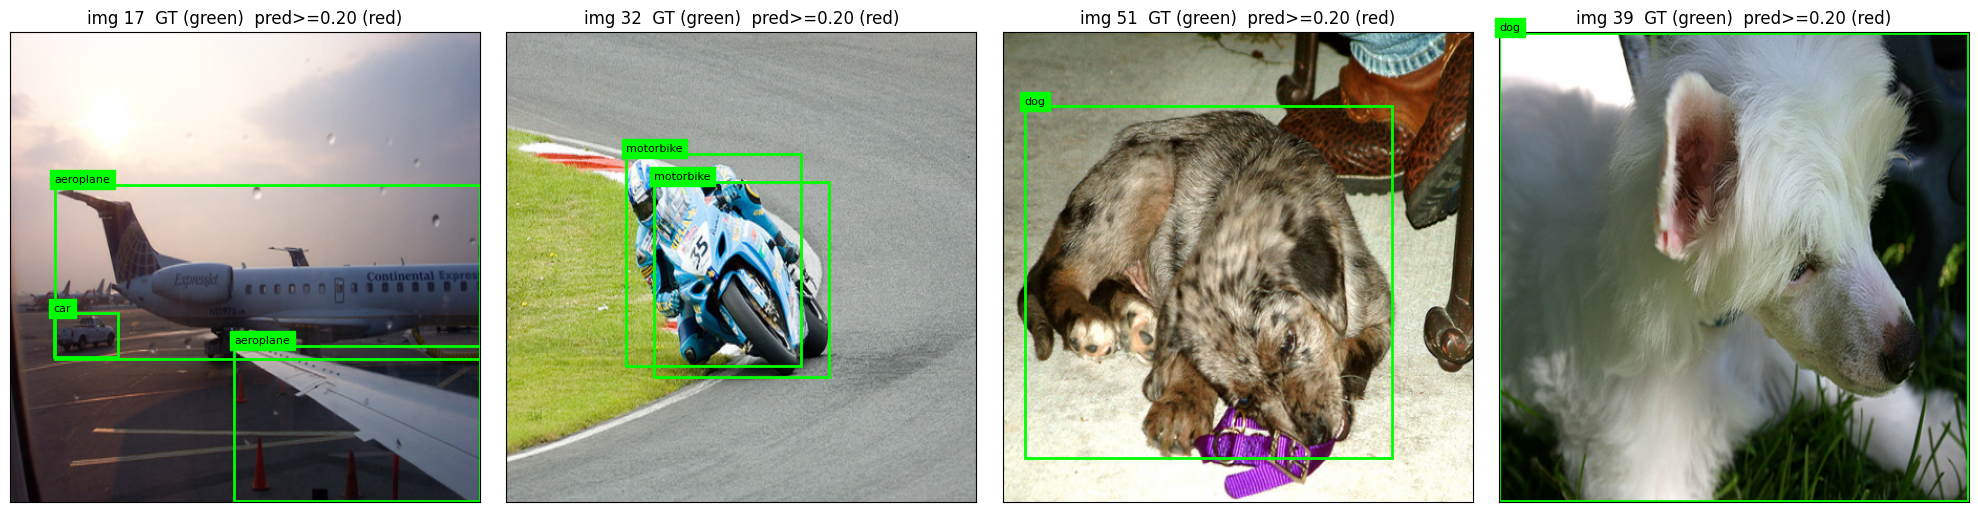

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

VIZ_SCORE_THRESH = 0.20  # use a friendlier threshold for the eyeball test
N_VIZ = 4

# Grab one batch worth of val data with images we can show.
viz_x, viz_y = voc_image_target_batch_fast(
    REPO_ROOT, BATCH_SIZE, seed=12345, batch_index=0,
    data_root=VOC_DATA_ROOT, split="val", size=IMG_SIZE,
    s=S, b=B, c=C, augment=False,
)
viz_logits = yolo.forward(viz_x)
viz_pred_grid = cp.asnumpy(viz_logits.reshape(-1, S, S, B * 5 + C))
viz_tgt_grid = cp.asnumpy(viz_y)
viz_imgs = cp.asnumpy(viz_x)  # (N, 3, H, W) float32 in [0, 1]

rng = np.random.default_rng(0)
sample_idx = rng.choice(viz_imgs.shape[0], size=min(N_VIZ, viz_imgs.shape[0]), replace=False)

fig, axes = plt.subplots(1, len(sample_idx), figsize=(5 * len(sample_idx), 5))
if len(sample_idx) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_idx):
    img = np.transpose(viz_imgs[idx], (1, 2, 0))
    h, w = img.shape[:2]
    ax.imshow(np.clip(img, 0.0, 1.0))
    ax.set_xticks([]); ax.set_yticks([])

    gt_boxes, gt_classes = decode_targets(viz_tgt_grid[idx])
    pr_boxes, pr_scores, pr_classes = decode_predictions(viz_pred_grid[idx], score_thresh=VIZ_SCORE_THRESH)
    pr_boxes, pr_scores, pr_classes = nms_per_class(pr_boxes, pr_scores, pr_classes, NMS_IOU_THRESH)

    for (x1, y1, x2, y2), cls in zip(gt_boxes, gt_classes):
        rect = mpatches.Rectangle((x1 * w, y1 * h), (x2 - x1) * w, (y2 - y1) * h,
                                  linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1 * w, y1 * h - 2, VOC_CLASS_NAMES[int(cls)],
                color="black", backgroundcolor="lime", fontsize=8)

    for (x1, y1, x2, y2), cls, score in zip(pr_boxes, pr_classes, pr_scores):
        rect = mpatches.Rectangle((x1 * w, y1 * h), (x2 - x1) * w, (y2 - y1) * h,
                                  linewidth=2, edgecolor="red", facecolor="none", linestyle="--")
        ax.add_patch(rect)
        ax.text(x1 * w, y2 * h + 12, f"{VOC_CLASS_NAMES[int(cls)]}:{score:.2f}",
                color="white", backgroundcolor="red", fontsize=8)

    ax.set_title(f"img {idx}  GT (green)  pred>={VIZ_SCORE_THRESH:.2f} (red)")

plt.tight_layout()
plt.show()

## Diagnostic: overfit a single image

If the forward / loss / gradient / backward / optimizer path is correct, a model
should be able to overfit a **single image** to near-zero loss in a few hundred
SGD steps. This is the cheapest, sharpest test of training-stack correctness.

Two experiments are run in parallel on the same val image:

1. **Fresh model (random init).** If loss → ~0, the entire training machinery is
   fine and the production-training failure must live in the *recipe* — LR
   schedule, warmup, augmentation, BN momentum, lambda balance, etc.
2. **From the epoch-60 checkpoint.** If the trained model can also drive loss to
   near 0 on one image, the head is still plastic and the weights aren't truly
   collapsed — the production training simply got stuck in a poor basin.

If **neither** can overfit, there is a bug in `loss.py` / `yolo.backward()` /
the head — and the priority becomes finding it before any more training time
is spent.

We also compare **train-mode** loss (uses per-batch BN stats) against
**eval-mode** loss (uses BN running averages) on the *same* weights. A large
gap (the post-training sanity check showed 6.20 vs 43.29 on the same data) is a
signature of stale BN running statistics.

GPU memory after cleanup: used=0.15 GB  reserved=2.35 GB
single image x: (1, 3, 448, 448) float32
single image y: (1, 7, 7, 30) float32
# GT objects in this image grid: 1

=== experiment B: overfit starting from the epoch-60 checkpoint ===
  [warm] step    0  train_loss=  7.9853
  [warm] step   25  train_loss=  5.5560
  [warm] step   50  train_loss=  1.2448
  [warm] step   75  train_loss=  2.9400
  [warm] step  100  train_loss=  2.8893
  [warm] step  125  train_loss=  0.7774
  [warm] step  150  train_loss=  4.5065
  [warm] step  175  train_loss=  1.6782
  [warm] step  200  train_loss=  0.7649
  [warm] step  225  train_loss=  0.7220
  [warm] step  250  train_loss=  1.2887
  [warm] step  275  train_loss=  0.2766
  [warm] step  299  train_loss=  0.5258
  [warm] DONE in 39.2s  final train-mode loss=  0.5309  eval-mode loss=  0.2271  BN gap= -0.3038
  [warm] eval-mode logits stats: mean=+0.0662 std=0.2766 min=-0.5261 max=+4.5137
GPU memory after dropping warm: used=0.15 GB  reserved=2.35 GB

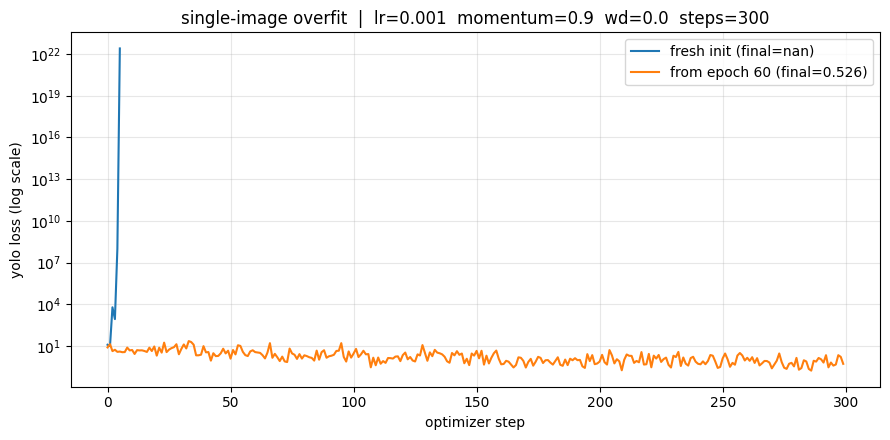

In [12]:
import gc
import time

from loss import yolo_loss, yolo_loss_grad

OVERFIT_STEPS = 300
OVERFIT_LR = 1e-3
OVERFIT_MOMENTUM = 0.9
OVERFIT_WD = 0.0  # no regularization for a pure capacity test
OVERFIT_LOG_EVERY = 25


def _free_gpu(*names):
    """Drop globals by name and release CuPy's memory pool back to the driver."""
    g = globals()
    for n in names:
        if n in g:
            del g[n]
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()


# The eval section above held onto a full YOLO + the entire val prediction
# cache + the viz batch. Drop everything we don't need before allocating two
# more YOLOs back-to-back. Without this, Colab's 40 GB GPU OOMs.
_free_gpu(
    "yolo",
    "all_preds", "all_gts",
    "viz_x", "viz_y", "viz_logits", "viz_pred_grid", "viz_tgt_grid", "viz_imgs",
)
mempool = cp.get_default_memory_pool()
print(
    f"GPU memory after cleanup: used={mempool.used_bytes()/1e9:.2f} GB  "
    f"reserved={mempool.total_bytes()/1e9:.2f} GB"
)


# Pull a single (image, target) pair from the val split (no augmentation).
_x_batch, _y_batch = voc_image_target_batch_fast(
    REPO_ROOT, BATCH_SIZE, seed=99, batch_index=0,
    data_root=VOC_DATA_ROOT, split="val", size=IMG_SIZE,
    s=S, b=B, c=C, augment=False,
)
x_one = _x_batch[0:1].copy()
y_one = _y_batch[0:1].copy()
del _x_batch, _y_batch
_free_gpu()
print(f"single image x: {x_one.shape} {x_one.dtype}")
print(f"single image y: {y_one.shape} {y_one.dtype}")
n_gt_objs = int(cp.asnumpy(y_one[..., 4] > 0).sum())
print(f"# GT objects in this image grid: {n_gt_objs}")


def _silent_forward_method(self, x):
    for layer in self.backbone:
        x = layer.forward(x)
    for layer in self.head:
        x = layer.forward(x)
    return x


def _overfit_one_image(model, label):
    """Run OVERFIT_STEPS of SGD on (x_one, y_one). Returns the per-step train losses."""
    model.init_optimizer()
    train_losses = []
    t0 = time.time()
    for step in range(OVERFIT_STEPS):
        model.train()
        logits = model.forward(x_one)
        loss = yolo_loss(logits, y_one, S=S, B=B, C=C)
        grad = yolo_loss_grad(logits, y_one, S=S, B=B, C=C)
        model.zero_grad()
        model.backward(grad)
        model.sgd_momentum_step(OVERFIT_LR, OVERFIT_MOMENTUM, OVERFIT_WD)
        train_losses.append(float(loss))
        if step % OVERFIT_LOG_EVERY == 0 or step == OVERFIT_STEPS - 1:
            print(f"  [{label}] step {step:4d}  train_loss={float(loss):8.4f}")
    dt = time.time() - t0

    # Compare train-mode vs eval-mode loss on the *same* image with the *same* weights.
    model.train()
    train_mode_loss = float(yolo_loss(model.forward(x_one), y_one, S=S, B=B, C=C))
    model.eval()
    eval_mode_loss = float(yolo_loss(model.forward(x_one), y_one, S=S, B=B, C=C))
    eval_logits = cp.asnumpy(model.forward(x_one).reshape(-1, S, S, B * 5 + C))[0]
    print(
        f"  [{label}] DONE in {dt:.1f}s  "
        f"final train-mode loss={train_mode_loss:8.4f}  "
        f"eval-mode loss={eval_mode_loss:8.4f}  "
        f"BN gap={eval_mode_loss - train_mode_loss:+8.4f}"
    )
    print(
        f"  [{label}] eval-mode logits stats: "
        f"mean={eval_logits.mean():+.4f} std={eval_logits.std():.4f} "
        f"min={eval_logits.min():+.4f} max={eval_logits.max():+.4f}"
    )
    return train_losses


# Run experiment B (warm-start) FIRST, then drop it before allocating the
# fresh model. This keeps `fresh` alive at the end so Cell 20 can visualize it.

print("\n=== experiment B: overfit starting from the epoch-60 checkpoint ===")
warm = YOLO(num_classes=C)
warm.load_weights(CKPT_PATH)
warm.forward = types.MethodType(_silent_forward_method, warm)
losses_warm = _overfit_one_image(warm, "warm")
_free_gpu("warm")
print(
    f"GPU memory after dropping warm: used={mempool.used_bytes()/1e9:.2f} GB  "
    f"reserved={mempool.total_bytes()/1e9:.2f} GB"
)

print("\n=== experiment A: overfit a fresh-init model on one image ===")
fresh = YOLO(num_classes=C)
fresh.forward = types.MethodType(_silent_forward_method, fresh)
losses_fresh = _overfit_one_image(fresh, "fresh")

# ---- plot loss curves -----------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(losses_fresh, label=f"fresh init (final={losses_fresh[-1]:.3f})")
ax.plot(losses_warm, label=f"from epoch 60 (final={losses_warm[-1]:.3f})")
ax.set_yscale("log")
ax.set_xlabel("optimizer step")
ax.set_ylabel("yolo loss (log scale)")
ax.set_title(
    f"single-image overfit  |  lr={OVERFIT_LR}  momentum={OVERFIT_MOMENTUM}  "
    f"wd={OVERFIT_WD}  steps={OVERFIT_STEPS}"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

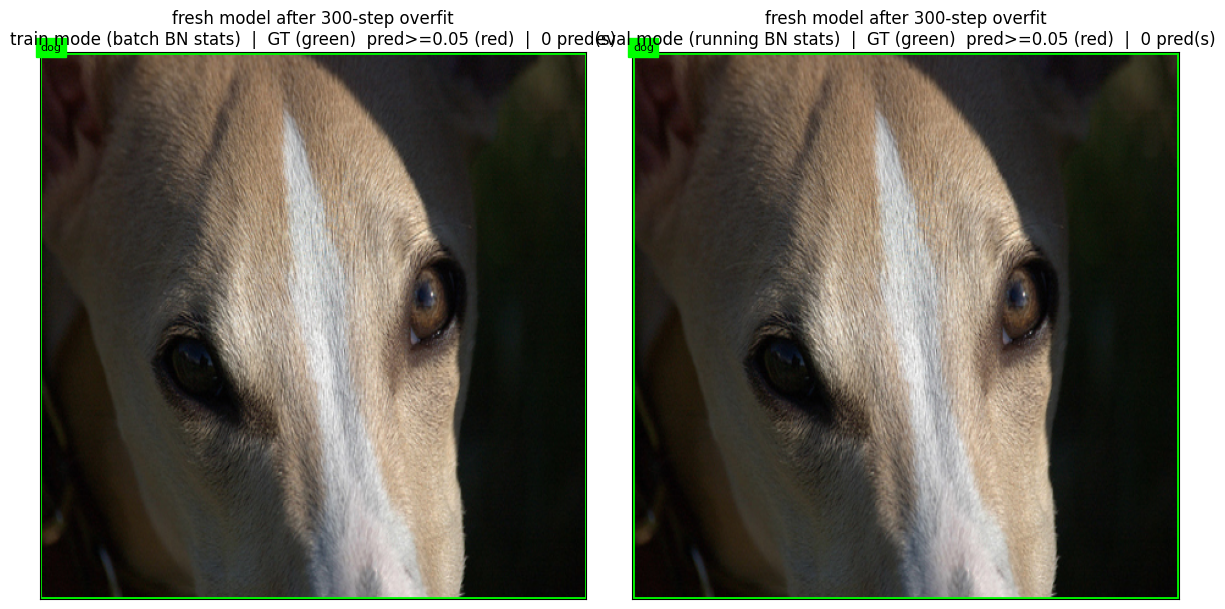

In [13]:
# Decode the fresh-overfit model's predictions on the same image, in BOTH
# train mode (uses exact batch BN stats — best case) and eval mode (uses BN
# running averages updated only from this single image's stats — worst case).
# Visualizing both makes any train/eval gap directly visible.

OVERFIT_VIZ_SCORE_THRESH = 0.05

fresh.train()
pred_grid_train = cp.asnumpy(fresh.forward(x_one).reshape(-1, S, S, B * 5 + C))[0]
fresh.eval()
pred_grid_eval = cp.asnumpy(fresh.forward(x_one).reshape(-1, S, S, B * 5 + C))[0]
gt_grid = cp.asnumpy(y_one)[0]
img = np.transpose(cp.asnumpy(x_one)[0], (1, 2, 0))
img_h, img_w = img.shape[:2]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, pred_grid, mode_label in zip(
    axes,
    [pred_grid_train, pred_grid_eval],
    ["train mode (batch BN stats)", "eval mode (running BN stats)"],
):
    ax.imshow(np.clip(img, 0.0, 1.0))
    ax.set_xticks([]); ax.set_yticks([])

    gt_boxes, gt_classes = decode_targets(gt_grid)
    pr_boxes, pr_scores, pr_classes = decode_predictions(
        pred_grid, score_thresh=OVERFIT_VIZ_SCORE_THRESH
    )
    pr_boxes, pr_scores, pr_classes = nms_per_class(
        pr_boxes, pr_scores, pr_classes, NMS_IOU_THRESH
    )

    for (x1, y1, x2, y2), cls in zip(gt_boxes, gt_classes):
        ax.add_patch(mpatches.Rectangle(
            (x1 * img_w, y1 * img_h), (x2 - x1) * img_w, (y2 - y1) * img_h,
            linewidth=2, edgecolor="lime", facecolor="none",
        ))
        ax.text(x1 * img_w, y1 * img_h - 2, VOC_CLASS_NAMES[int(cls)],
                color="black", backgroundcolor="lime", fontsize=8)

    for (x1, y1, x2, y2), cls, score in zip(pr_boxes, pr_classes, pr_scores):
        ax.add_patch(mpatches.Rectangle(
            (x1 * img_w, y1 * img_h), (x2 - x1) * img_w, (y2 - y1) * img_h,
            linewidth=2, edgecolor="red", facecolor="none", linestyle="--",
        ))
        ax.text(x1 * img_w, y2 * img_h + 12,
                f"{VOC_CLASS_NAMES[int(cls)]}:{score:.2f}",
                color="white", backgroundcolor="red", fontsize=8)

    ax.set_title(
        f"fresh model after {OVERFIT_STEPS}-step overfit\n"
        f"{mode_label}  |  GT (green)  pred>={OVERFIT_VIZ_SCORE_THRESH:.2f} (red)  "
        f"|  {len(pr_boxes)} pred(s)"
    )

plt.tight_layout()
plt.show()

## Diagnostic: did the classification head collapse?

The mAP table shows `person` ≈ 1.5% and **every** other class exactly 0.0%, while
the qualitative cell shows boxes drawn around real objects. The hypothesis is
that the box regression head learned but the class head collapsed to a single
mode (probably `person`, the most common class in VOC).

This cell tests that directly on one val batch with two views:

1. **What the model actually outputs after NMS.** Histogram of predicted class
   IDs across all kept detections (objectness × class_prob > `SCORE_THRESH`).
   If the model is healthy this distribution roughly tracks VOC class
   frequencies; if collapsed, one bar dominates.
2. **What the class head encodes per cell.** For every grid cell of every
   image, take `argmax(class_probs)` — totally ignoring objectness. This is
   the cleanest view of the class head's selectivity. A healthy head produces
   a varied histogram; a collapsed head produces one tall bar.

We also print the **per-class mean** of `class_probs` over all cells in the
batch. A collapsed head will have one class with a clearly larger mean than
the rest.

In [14]:
# The earlier overfit cell freed the production `yolo` and the `fresh` model is
# still around but irrelevant here — we want the *production checkpoint*, in eval
# mode, behaving exactly as the mAP cell saw it.
_free_gpu("fresh", "warm", "yolo", "x_one", "y_one")
mempool = cp.get_default_memory_pool()
print(
    f"GPU memory after cleanup: used={mempool.used_bytes()/1e9:.2f} GB  "
    f"reserved={mempool.total_bytes()/1e9:.2f} GB"
)

yolo = YOLO(num_classes=C)
yolo.load_weights(CKPT_PATH)
yolo.eval()
yolo.forward = types.MethodType(_silent_forward_method, yolo)

# Pull one fixed val batch (no augmentation, deterministic seed) so any rerun
# is comparable.
diag_x, diag_y = voc_image_target_batch_fast(
    REPO_ROOT, BATCH_SIZE, seed=0, batch_index=0,
    data_root=VOC_DATA_ROOT, split="val", size=IMG_SIZE,
    s=S, b=B, c=C, augment=False,
)
diag_logits = yolo.forward(diag_x)
diag_pred_grid = cp.asnumpy(diag_logits.reshape(-1, S, S, B * 5 + C))
n_imgs = diag_pred_grid.shape[0]
print(f"Inference on {n_imgs} val images, grid={S}x{S}, B={B}, C={C}")

# ---------------------------------------------------------------------------
# View 1: histogram of predicted class IDs across all kept detections (NMS-ed).
# ---------------------------------------------------------------------------
det_class_counts = np.zeros(C, dtype=np.int64)
total_detections = 0
for i in range(n_imgs):
    boxes, scores, classes = decode_predictions(diag_pred_grid[i])
    boxes, scores, classes = nms_per_class(boxes, scores, classes, NMS_IOU_THRESH)
    if classes.size:
        np.add.at(det_class_counts, classes, 1)
        total_detections += classes.size

print(f"\n--- View 1: predicted classes after NMS (score > {SCORE_THRESH}) ---")
print(f"total kept detections across {n_imgs} images: {total_detections}")
order = np.argsort(-det_class_counts)
max_count = int(det_class_counts.max()) if total_detections else 0
for rank, c_id in enumerate(order):
    n = int(det_class_counts[c_id])
    bar_len = int(40 * n / max(max_count, 1))
    pct = 100.0 * n / max(total_detections, 1)
    print(f"  {VOC_CLASS_NAMES[c_id]:<14s} {n:6d} ({pct:5.1f}%) {'#' * bar_len}")

# ---------------------------------------------------------------------------
# View 2: per-cell argmax of the class head, IGNORING objectness.
# ---------------------------------------------------------------------------
class_probs = diag_pred_grid[..., B * 5:]              # (N, S, S, C)
per_cell_argmax = class_probs.argmax(axis=-1).reshape(-1)  # (N*S*S,)
cell_class_counts = np.bincount(per_cell_argmax, minlength=C)

print(f"\n--- View 2: per-cell argmax(class_probs), ignoring objectness ---")
print(f"total cells: {cell_class_counts.sum()}  (= {n_imgs} imgs * {S*S} cells)")
order = np.argsort(-cell_class_counts)
max_count = int(cell_class_counts.max())
for c_id in order:
    n = int(cell_class_counts[c_id])
    bar_len = int(40 * n / max(max_count, 1))
    pct = 100.0 * n / cell_class_counts.sum()
    print(f"  {VOC_CLASS_NAMES[c_id]:<14s} {n:6d} ({pct:5.1f}%) {'#' * bar_len}")

# ---------------------------------------------------------------------------
# View 3: mean class-probability vector across ALL cells in the batch.
# A collapsed class head has one entry clearly larger than the others.
# ---------------------------------------------------------------------------
mean_class_probs = class_probs.reshape(-1, C).mean(axis=0)
std_class_probs = class_probs.reshape(-1, C).std(axis=0)
print(f"\n--- View 3: mean class-probability per class (over all cells) ---")
order = np.argsort(-mean_class_probs)
for c_id in order:
    print(
        f"  {VOC_CLASS_NAMES[c_id]:<14s} "
        f"mean={mean_class_probs[c_id]:+.4f}  std={std_class_probs[c_id]:.4f}"
    )

# Quick verdict.
top_cell_share = cell_class_counts.max() / cell_class_counts.sum()
print(
    f"\nVerdict: top class owns {top_cell_share*100:.1f}% of all cell argmaxes. "
    f"{'CLASS HEAD COLLAPSED.' if top_cell_share > 0.5 else 'class head looks varied.'}"
)

del diag_x, diag_y, diag_logits, diag_pred_grid
_free_gpu()

GPU memory after cleanup: used=0.15 GB  reserved=2.35 GB
Inference on 64 val images, grid=7x7, B=2, C=20

--- View 1: predicted classes after NMS (score > 0.05) ---
total kept detections across 64 images: 1276
  person           1276 (100.0%) ########################################
  aeroplane           0 (  0.0%) 
  bird                0 (  0.0%) 
  bicycle             0 (  0.0%) 
  bottle              0 (  0.0%) 
  bus                 0 (  0.0%) 
  car                 0 (  0.0%) 
  boat                0 (  0.0%) 
  cat                 0 (  0.0%) 
  chair               0 (  0.0%) 
  diningtable         0 (  0.0%) 
  cow                 0 (  0.0%) 
  dog                 0 (  0.0%) 
  horse               0 (  0.0%) 
  motorbike           0 (  0.0%) 
  pottedplant         0 (  0.0%) 
  sheep               0 (  0.0%) 
  sofa                0 (  0.0%) 
  train               0 (  0.0%) 
  tvmonitor           0 (  0.0%) 

--- View 2: per-cell argmax(class_probs), ignoring objectness ---
tot